# btc commission fees analysis     

### import wrappers

In [23]:
import data
import econometrics as ec

### fetch dataset

In [24]:
df = data.build_master_dataset()
ec.summary_stats(df, cols=['fees_btc', 'price_usd', 'mempool_bytes'])

,N,mean,median,std,min,max,skew,kurtosis
fees_btc,5619,5.343868e+01,2.292718e+01,9.458254e+01,0.017654,1.495946e+03,4.962668,36.699876
price_usd,5619,2.162644e+04,6.682680e+03,3.069889e+04,0.300000,1.247767e+05,1.543466,1.368039
mempool_bytes,3628,3.563670e+07,6.728946e+06,5.441201e+07,331706.630208,3.761115e+08,2.373752,7.151477


### main regression and stationarity

In [25]:
ec.stationarity_table(df, cols=['log_fees_btc', 'log_price_usd', 'log_mempool_bytes',
                                 'd_log_fees_btc', 'd_log_price_usd', 'd_log_mempool_bytes'])

m1 = ec.run_ols('d_log_fees_btc ~ d_log_price_usd', df)
m2 = ec.run_ols('d_log_fees_btc ~ d_log_price_usd + d_log_mempool_bytes', df)
m3 = ec.run_ols('d_log_fees_btc ~ d_log_price_usd + d_log_mempool_bytes + d_log_n_transactions', df)
print(ec.compare_models([m1, m2, m3], names=['Price only', '+Mempool', 'Full']))


                     Price only  +Mempool    Full  
---------------------------------------------------
Intercept            0.0002     -0.0012   -0.0013  
                     (0.0023)   (0.0025)  (0.0024) 
d_log_price_usd      0.1927     0.3648*** 0.2818** 
                     (0.1591)   (0.1230)  (0.1223) 
d_log_mempool_bytes             0.1972*** 0.1764***
                                (0.0080)  (0.0084) 
d_log_n_transactions                      0.5798***
                                          (0.0546) 
R-squared            0.0006     0.2283    0.3249   
R-squared Adj.       0.0004     0.2278    0.3244   
Adj. R²              0.000      0.228     0.324    
N                    5618       3627      3627     
R²                   0.001      0.228     0.325    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [26]:
eras = data.split_by_halving(df)
for name, era_df in eras.items():
    n_mempool = era_df['d_log_mempool_bytes'].notna().sum()
    print(f'\n--- {name}  (rows={len(era_df)}, mempool obs={n_mempool}) ---')

    # Include mempool only if the era has enough of it; else price-only
    formula = 'd_log_fees_btc ~ d_log_price_usd'
    if n_mempool > 50:
        formula += ' + d_log_mempool_bytes'

    try:
        m = ec.run_ols(formula, era_df)
        print(f'formula: {formula}')
        print(m.summary())
    except Exception as e:
        print(f'  skipped ({type(e).__name__}): {e}')


--- era_1_pre_2012  (rows=697, mempool obs=0) ---
formula: d_log_fees_btc ~ d_log_price_usd
                            OLS Regression Results                            
Dep. Variable:         d_log_fees_btc   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3196
Date:                Fri, 22 May 2026   Prob (F-statistic):              0.572
Time:                        00:33:30   Log-Likelihood:                -672.15
No. Observations:                 696   AIC:                             1348.
Df Residuals:                     694   BIC:                             1357.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------

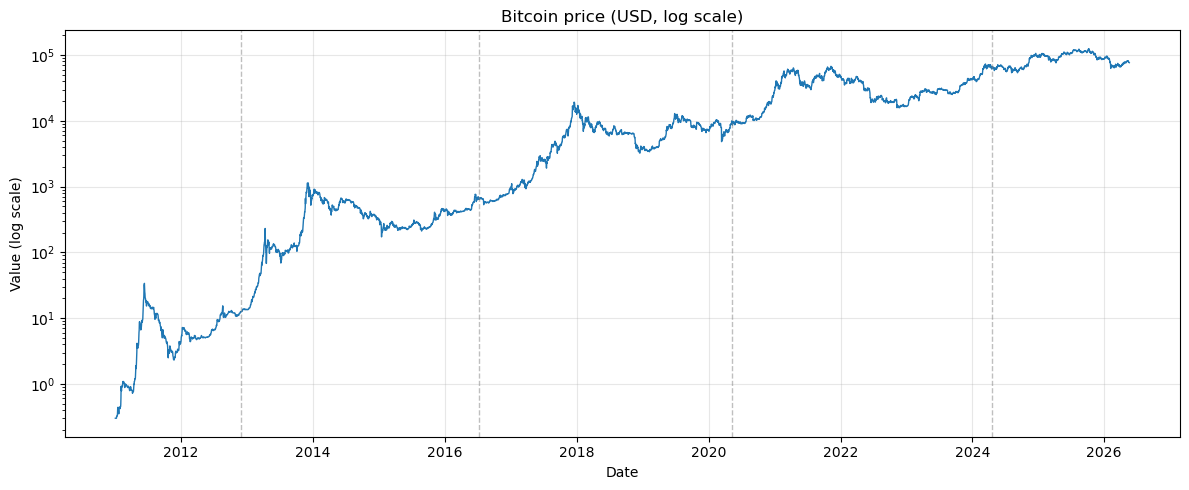

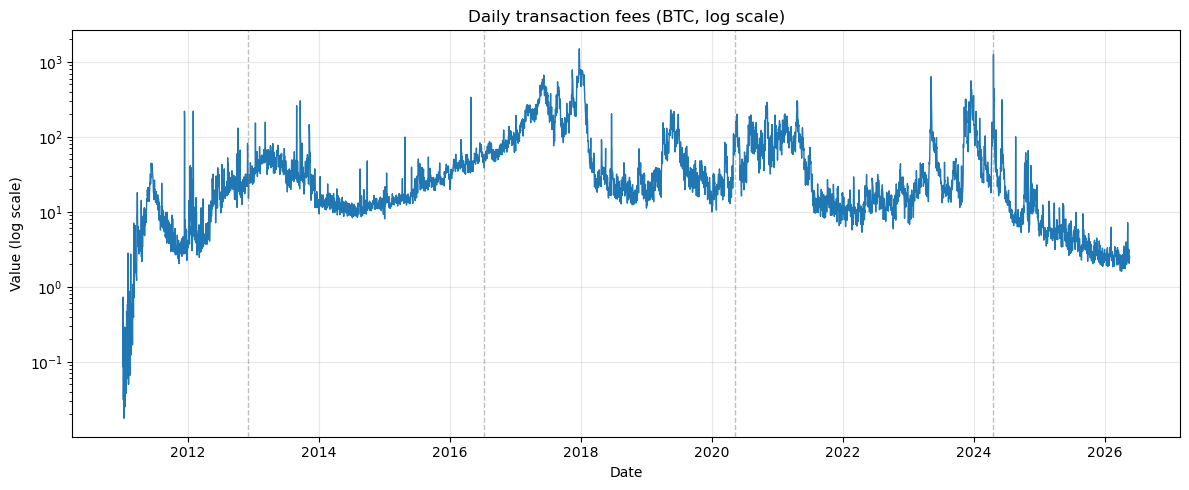

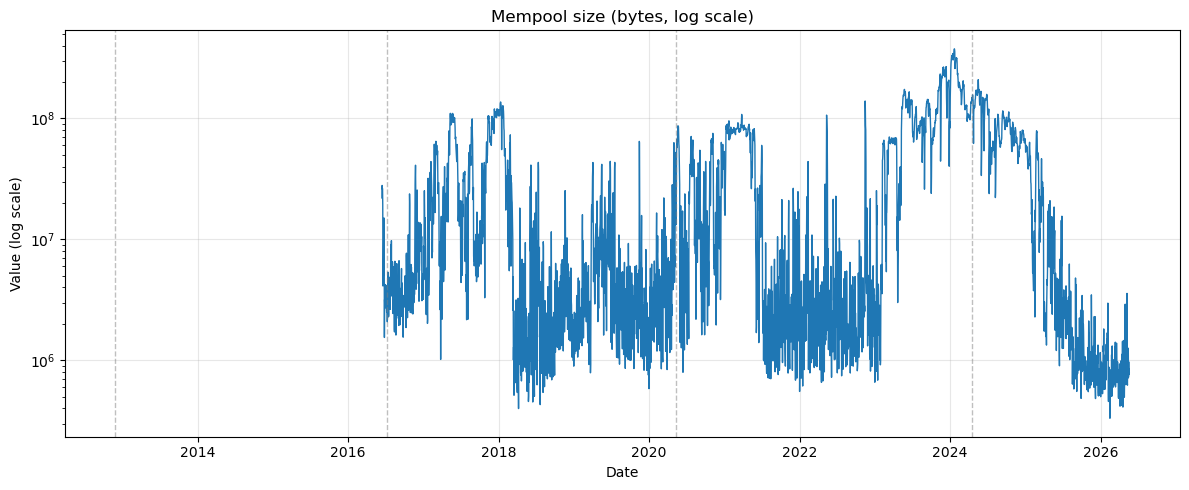

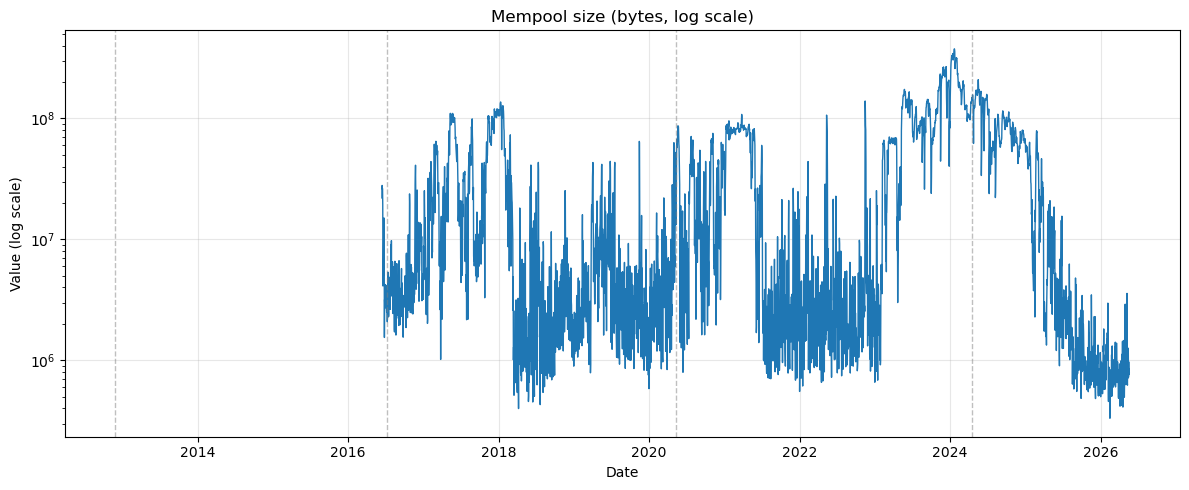

In [27]:
# 1. Bitcoin price, log scale, with halvings — the "here's the asset" chart
ec.plot_series(df, ['price_usd'], log=True, halvings=True,
               title='Bitcoin price (USD, log scale)')

# 2. Fees in BTC, log scale, with halvings — your dependent variable
ec.plot_series(df, ['fees_btc'], log=True, halvings=True,
               title='Daily transaction fees (BTC, log scale)')

# 3. Mempool size — the variable that turns out to matter most
ec.plot_series(df, ['mempool_bytes'], log=True, halvings=True,
               title='Mempool size (bytes, log scale)')